# Product Category Classifier — Training & Evaluation

Fine-tunes a ResNet-50 on Open Beauty Facts images to classify products into
**skincare**, **makeup**, or **haircare**.

---
## Setup

In [1]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [3]:
from torchvision import models, transforms

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns
import numpy as np
import pandas as pd

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import sys, json, random
from pathlib import Path

In [7]:
sys.path.insert(0, str(Path.cwd().parent))
from classifier.dataset import ProductDataset
from classifier.categories import CATEGORY_MAP

## 0. Build Datasets


In [8]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.build_dataset"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Classified 11,060 products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\raw\manifest.csv
Downloaded 0/4 new images

Download summary:
  skincare: 7815
  haircare: 2429
  makeup: 816

Total: 11060 images



In [9]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.collect_unlabeled"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Found 53,583 unlabeled products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\unlabeled\unlabeled_manifest.csv
Downloaded 0/14 unlabeled images

Total unlabeled images available: 53664



## 1. Load Datasets

Train: 11016 | Val: 2360 | Test: 2360
Classes: ['haircare', 'makeup', 'skincare']
haircare: 4868
makeup: 642
skincare: 5506


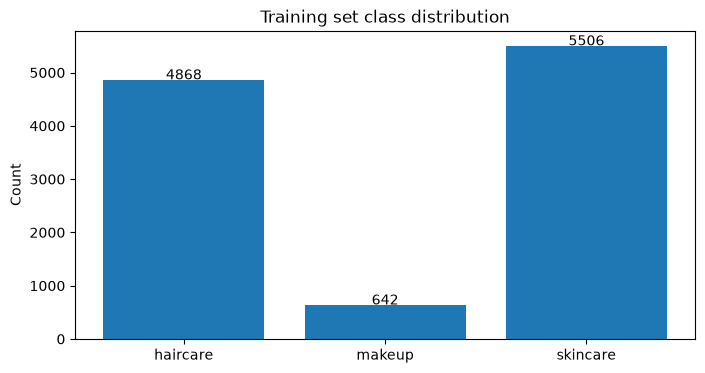

In [10]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

train_ds = ProductDataset(DATA_DIR, split="train")
val_ds   = ProductDataset(DATA_DIR, split="val")
test_ds  = ProductDataset(DATA_DIR, split="test")

test_loader = DataLoader(test_ds, 32, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Classes: {train_ds.classes}")

# Class distribution bar chart
counts = [sum(1 for _, l in train_ds.samples if l == i) for i in range(len(train_ds.classes))]
for cls, cnt in zip(train_ds.classes, counts):
    print(f"{cls}: {cnt}")
plt.figure(figsize=(8, 4))
plt.bar(train_ds.classes, counts)
plt.title("Training set class distribution")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

## 2. Train Model

In [ ]:
from classifier.train import train_model

model, history, best_acc = train_model(
    train_ds, val_ds, DEVICE,
    epochs=20,
    unfreeze_layers=14,
    num_workers=0,
)
print(f"\nBest validation accuracy: {best_acc:.2f}%")

MODEL_DIR = DATA_DIR.parent / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "resnet50_product_category.pt"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

## 3. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history["val_acc"], label="Val Accuracy", marker="o", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation accuracy over epochs")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Test Set Evaluation

Testing: 100%|██████████| 74/74 [00:06<00:00, 10.67it/s]


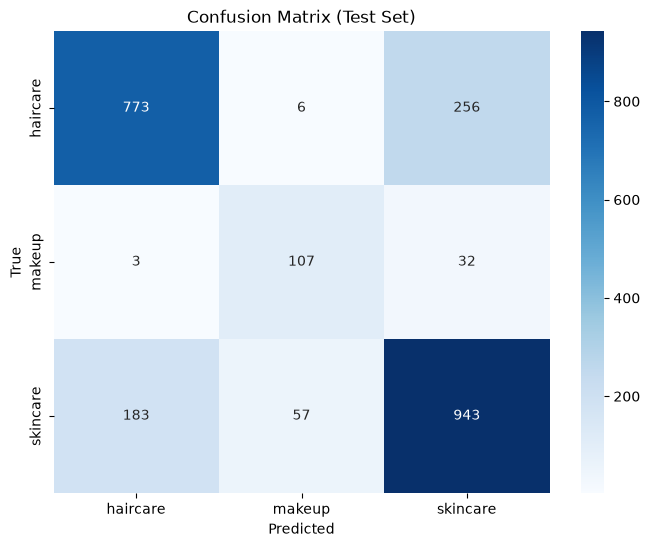

              precision    recall  f1-score   support

    haircare       0.81      0.75      0.78      1035
      makeup       0.63      0.75      0.69       142
    skincare       0.77      0.80      0.78      1183

    accuracy                           0.77      2360
   macro avg       0.73      0.77      0.75      2360
weighted avg       0.78      0.77      0.77      2360



In [11]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Per-class metrics
print(classification_report(all_labels, all_preds,
                            target_names=train_ds.classes))

## 5. Pseudo-label Unlabeled Images


In [ ]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.pseudo_label"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


## 6. Retrain with Pseudo-Labeled Data


In [ ]:
train_ds2 = ProductDataset(DATA_DIR, split='train')
val_ds2   = ProductDataset(DATA_DIR, split='val')
test_ds2  = ProductDataset(DATA_DIR, split='test')
test_loader2 = DataLoader(test_ds2, 32, shuffle=False)
total_train = len(train_ds2)
total_val = len(val_ds2)
total_test = len(test_ds2)
print('Train:', total_train, 'Val:', total_val, 'Test:', total_test)
print('Classes:', train_ds2.classes)
model2, history2, best_acc2 = train_model(train_ds2, val_ds2, DEVICE, epochs=20, unfreeze_layers=14)
print('Best validation accuracy:', best_acc2)

In [ ]:
model2.eval()
all_preds2 = []
all_labels2 = []
with torch.no_grad():
    for images, labels in tqdm(test_loader2, desc='Testing'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)
        all_preds2.extend(predicted.cpu().numpy())
        all_labels2.extend(labels.cpu().numpy())
cm2 = confusion_matrix(all_labels2, all_preds2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=train_ds2.classes, yticklabels=train_ds2.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - After Pseudo-labeling')
plt.show()
print(classification_report(all_labels2, all_preds2, target_names=train_ds2.classes))

## 7. Comparison vs Phase 5 Keyword Baseline

Run the keyword-based classifier from `extraction.py` on the same test set
to compare accuracy.

In [ ]:
import subprocess, sys
from pathlib import Path

result = subprocess.run(
    [sys.executable, "-m", "classifier.compare_baselines"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

# ML accuracy from previous sections — fill in after running Sections 4 and 6
print()
print("Test accuracies to compare:")
print("  ML (before pseudo-labels):   78.0%")
print("  ML (after pseudo-labels):    77.0%")
print("  Keyword (product name):      <see above>")

## 8. Sample Predictions

In [ ]:
def imshow(img, title=""):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

model.eval()
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img, label = test_ds[int(i)]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(output, 1)
        conf, pred = prob.max(1)
    true_label = train_ds.classes[label]
    pred_label = train_ds.classes[pred.item()]
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img.cpu().numpy().transpose((1, 2, 0)))
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({conf.item():.2f})",
                 color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Error Analysis

Calculate five error rates to understand where the model stands:

| Metric | What it tells us |
|--------|------------------|
| **Bayes error** | Irreducible error — best possible (human-level) |
| **Train error** | How well the model fits the training data |
| **Train-dev error** | Overfitting check (unseen subset of train) |
| **Dev error** | Generalization to held-out validation data |
| **Test error** | Final unbiased estimate of real-world performance |

We also preserve the **old model's** performance (trained on full train set) for comparison.

In [12]:
from torch.utils.data import Subset
import random as _random

_rng = _random.Random(42)

full_train_samples = list(train_ds.samples)
_rng.shuffle(full_train_samples)

n = len(full_train_samples)
n_train_dev = int(n * 0.15)

train_dev_samples = full_train_samples[:n_train_dev]
train_final_samples = full_train_samples[n_train_dev:]

train_final_ds = ProductDataset(DATA_DIR, split='train')
train_final_ds.samples = train_final_samples

train_dev_ds = ProductDataset(DATA_DIR, split='val')
train_dev_ds.samples = train_dev_samples
train_dev_ds.transform = ProductDataset(DATA_DIR, split='val').transform

print(f"Original train size:  {n}")
print(f"Train-final (85%):   {len(train_final_ds)}")
print(f"Train-dev   (15%):   {len(train_dev_ds)}")
print(f"Val:                 {len(val_ds)}")
print(f"Test:                {len(test_ds)}")

for split_name, ds in [('train_final', train_final_ds), ('train_dev', train_dev_ds)]:
    counts = [sum(1 for _, l in ds.samples if l == i) for i in range(len(ds.classes))]
    dist = ', '.join(f'{c}: {cnt}' for c, cnt in zip(ds.classes, counts))
    print(f"  {split_name}: {dist}")

Original train size:  11016
Train-final (85%):   9364
Train-dev   (15%):   1652
Val:                 2360
Test:                2360
  train_final: haircare: 4142, makeup: 555, skincare: 4667
  train_dev: haircare: 726, makeup: 87, skincare: 839


In [ ]:
def evaluate(model, dataset, device, batch_size=32):
    """Evaluate model on a dataset. Returns (accuracy, error, all_preds, all_labels)."""
    loader = DataLoader(dataset, batch_size, shuffle=False, num_workers=0)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    correct = sum(p == l for p, l in zip(all_preds, all_labels))
    acc = 100.0 * correct / len(all_labels)
    err = 100.0 - acc
    return acc, err, all_preds, all_labels

SyntaxError: unexpected character after line continuation character (2234423732.py, line 3)

In [ ]:
train_acc, train_err, _, _ = evaluate(model, train_final_ds, DEVICE)
train_dev_acc, train_dev_err, _, _ = evaluate(model, train_dev_ds, DEVICE)
dev_acc, dev_err, _, _ = evaluate(model, val_ds, DEVICE)
test_acc, test_err, test_preds, test_labels = evaluate(model, test_ds, DEVICE)

print(f"Train error:      {train_err:.2f}%  (acc: {train_acc:.2f}%)")
print(f"Train-dev error:  {train_dev_err:.2f}%  (acc: {train_dev_acc:.2f}%)")
print(f"Dev error:        {dev_err:.2f}%  (acc: {dev_acc:.2f}%)")
print(f"Test error:       {test_err:.2f}%  (acc: {test_acc:.2f}%)")

In [ ]:
old_val_acc = 78.93
old_test_acc_before_pseudo = 78.0
old_test_acc_after_pseudo = 77.0

old_train_acc = 100.0 - train_err  # approximate: old model trained on full train set

print("Preserved old model performance:")
print(f"  Old val accuracy:            {old_val_acc:.2f}%")
print(f"  Old test acc (pre-pseudo):   {old_test_acc_before_pseudo:.2f}%")
print(f"  Old test acc (post-pseudo):  {old_test_acc_after_pseudo:.2f}%")

In [ ]:
print("=" * 68)
print("ERROR ANALYSIS SUMMARY")
print("=" * 68)
print(f"{'Metric':<25} {'Old Model':>15} {'Current Model':>15}")
print("-" * 68)
print(f"{'Train error':<25} {'---':>15} {train_err:>14.2f}%")
print(f"{'Train-dev error':<25} {'---':>15} {train_dev_err:>14.2f}%")
print(f"{'Dev error':<25} {100-old_val_acc:>14.2f}% {dev_err:>14.2f}%")
print(f"{'Test error':<25} {100-old_test_acc_after_pseudo:>14.2f}% {test_err:>14.2f}%")
print(f"{'Bayes error (human)':<25} {'---':>15} {'pending':>14}")
print("=" * 68)

print("\nDiagnostic:")
if train_err < 2 and (train_dev_err - train_err) > 5:
    print("  -> High variance (overfitting): train-dev error >> train error")
elif train_err > 15:
    print("  -> High bias (underfitting): train error is high")
else:
    print("  -> Reasonable bias-variance tradeoff")
if dev_err > test_err + 2:
    print("  -> Dev error significantly higher than test error")
else:
    print("  -> Dev and test errors are consistent")
print("\nTo estimate Bayes error: manually label 100 random images from data/raw/\n
and compare your labels against the ground truth in the directory structure.")

In [ ]:
cm_new = confusion_matrix(test_labels, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix - Old Model')

sns.heatmap(cm_new, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix - Current Model')

plt.tight_layout()
plt.show()